In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"
]

df = pd.read_csv("pima-indians-diabetes.csv", names=columns)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
scalers = {
    "Raw": None,
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler()
}

datasets = {}

for name, scaler in scalers.items():
    if scaler is None:
        X_tr, X_te = X_train, X_test
    else:
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)
    
    datasets[name] = (X_tr, X_te)

In [5]:
models = {
    "LR": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(),
    "NB": GaussianNB(),
    "SVM": SVC()
}

In [6]:
results = []

for data_name, (X_tr, X_te) in datasets.items():
    for model_name, model in models.items():
        kfold = KFold(n_splits=10, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_tr, y_train, cv=kfold)
        
        results.append({
            "Data": data_name,
            "Model": model_name,
            "Accuracy": scores.mean()
        })

df_results = pd.DataFrame(results)

print(df_results)

        Data Model  Accuracy
0        Raw    LR  0.780363
1        Raw   KNN  0.720894
2        Raw    DT  0.726380
3        Raw    NB  0.750769
4        Raw   SVM  0.759958
5     MinMax    LR  0.758071
6     MinMax   KNN  0.735604
7     MinMax    DT  0.726485
8     MinMax    NB  0.750769
9     MinMax   SVM  0.761775
10  Standard    LR  0.776660
11  Standard   KNN  0.744934
12  Standard    DT  0.735604
13  Standard    NB  0.750769
14  Standard   SVM  0.776590


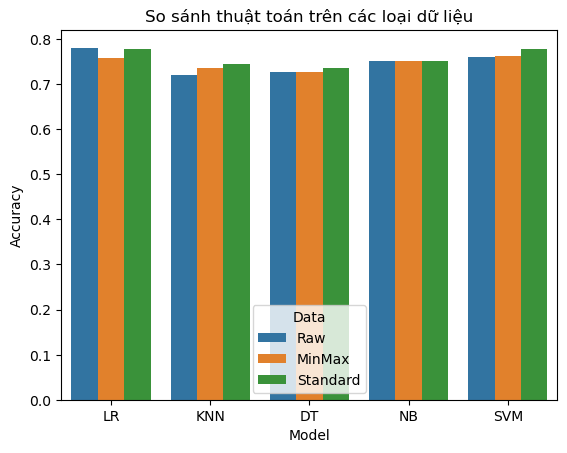

In [8]:
plt.figure()
sns.barplot(data=df_results, x="Model", y="Accuracy", hue="Data")
plt.title("So sánh thuật toán trên các loại dữ liệu")
plt.show()

In [9]:
best_row = df_results.loc[df_results["Accuracy"].idxmax()]
print("\nBest config:\n", best_row)

best_data = best_row["Data"]
best_model_name = best_row["Model"]

X_tr, X_te = datasets[best_data]
model = models[best_model_name]


Best config:
 Data             Raw
Model             LR
Accuracy    0.780363
Name: 0, dtype: object


In [10]:
model.fit(X_tr, y_train)
y_pred = model.predict(X_te)

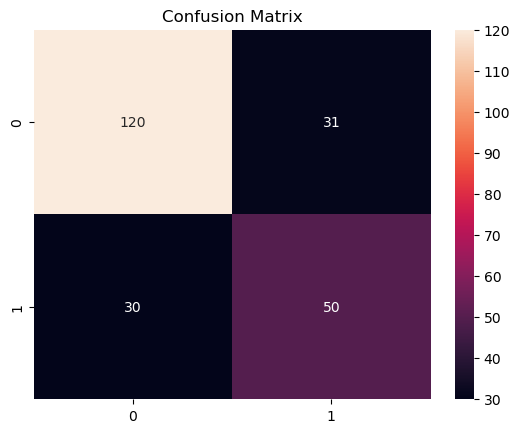

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [12]:
print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final Accuracy: 0.7359307359307359
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231

